## Qiskit -- Problem Set 4
Cristobal Lillo

In [3]:
import qiskit
from qiskit import *
import qiskit_ibm_runtime
import qiskit_aer

# 1: Deutsch's algorithm


In [19]:



q=QuantumRegister(2) 
c=ClassicalRegister(2)
deutsch = QuantumCircuit(q,c)
# NOT gates on q[1] and q[2]

deutsch.x(q[1])

# barrier to prevent gate reordering (not necessary, but makes visualization look nice) 
deutsch.barrier()

deutsch.h(q[1])
deutsch.h(q[0])

deutsch.barrier()

# f1(x) translates to a controlled not, control on i, target on o.
deutsch.cx(q[0], q[1])

deutsch.barrier()

deutsch.h(q[0])

deutsch.barrier()


# measurement gates
deutsch.measure(q[0], c[0])

In [20]:
deutsch.draw(initial_state=True)

░ ┌───┐ ░       ░ ┌───┐ ░ ┌─┐
q9_0: |0>──────░─┤ H ├─░───■───░─┤ H ├─░─┤M├
         ┌───┐ ░ ├───┤ ░ ┌─┴─┐ ░ └───┘ ░ └╥┘
q9_1: |0>┤ X ├─░─┤ H ├─░─┤ X ├─░───────░──╫─
         └───┘ ░ └───┘ ░ └───┘ ░       ░  ║ 
 c9: 0 2/═════════════════════════════════╩═
                                          0

In [22]:
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

In [25]:
backend = AerSimulator()
sampler = AerSampler()

In [26]:
# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
deutsch_isa = pm.run(deutsch)

In [27]:
job_sim = sampler.run([deutsch_isa], shots=4096)
result_sim = job_sim.result()[0] # Get results for the first circuit

In [28]:
# Print the DataBin to see what's inside
list(result_sim.data.keys())

['c9']

In [30]:
counts_sim = result_sim.data.c9.get_counts()
print(counts_sim)

{'01': 4096}


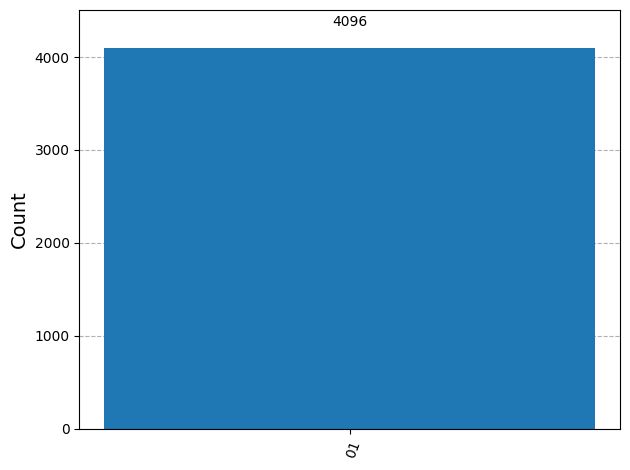

In [31]:
# Plot a histogram of the results
from qiskit.visualization import plot_histogram
plot_histogram(counts_sim)

## Remarks on the simulation

As predicted, deutsch's algorithm correctly one shots that U_f is of the 1 type. Though it is likely that the real device does not behave so nicely.

In [34]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Initialize the service
service = QiskitRuntimeService(instance="open-instance")

# Filter for real hardware (not simulators) that is currently operational
backend = service.least_busy(simulator=False, operational=True)
print(f"Running on: {backend.name}")

Running on: ibm_fez


In [35]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_deutsch = pm.run(deutsch)

In [36]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
# Initialize the Sampler for your backend
sampler = Sampler(mode=backend)

In [37]:
# Submit the job
job_exp = sampler.run([isa_deutsch])
job_exp.job_id()

'd6ndbvm9td6c73ao1ppg'

In [39]:
job_exp.status()

'DONE'

In [40]:
result_exp = job_exp.result()[0]


In [41]:
# Print the DataBin to see what's inside
list(result_exp.data.keys())

['c9']

In [42]:

counts_exp = result_exp.data.c9.get_counts()
print(counts_exp)

{'01': 3853, '00': 243}


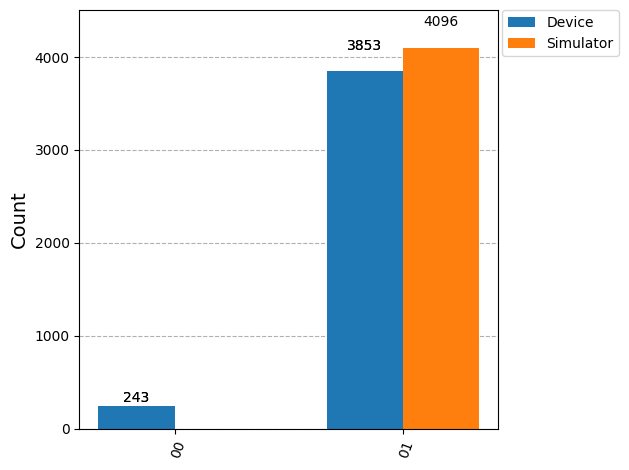

In [43]:
from qiskit.visualization import plot_histogram
plot_histogram([counts_exp,counts_sim], legend=['Device', 'Simulator'])

## Remarks on experimental results

As previously predicted, quantum device yielded close to theoretically predicted, though some noise did include the state 00 in the measurement distribution, something that theoretically should not be possible. All in all, these are good results with marginally low error.

# 2 - Bernstein-Vazirani algorithm

In [78]:



q=QuantumRegister(3) 
c=ClassicalRegister(2)
bv = QuantumCircuit(q,c)

# NOT gate on o.
bv.x(q[2])

# barrier to prevent gate reordering (not necessary, but makes visualization look nice) 
bv.barrier()
bv.h(q[2])
bv.h(q[1])
bv.h(q[0])

bv.barrier()

# f1(x) translates to a controlled not, control on i, target on o.
bv.cx(q[1], q[2])
bv.cx(q[0], q[2])
bv.barrier()

bv.h(q[0])
bv.h(q[1])
bv.h(q[2])

bv.barrier()


# measurement gates
bv.measure(q[0], c[0])
bv.measure(q[1], c[1])

In [79]:
bv.draw(initial_state=True)

░ ┌───┐ ░            ░ ┌───┐ ░ ┌─┐   
q18_0: |0>──────░─┤ H ├─░────────■───░─┤ H ├─░─┤M├───
                ░ ├───┤ ░        │   ░ ├───┤ ░ └╥┘┌─┐
q18_1: |0>──────░─┤ H ├─░───■────┼───░─┤ H ├─░──╫─┤M├
          ┌───┐ ░ ├───┤ ░ ┌─┴─┐┌─┴─┐ ░ ├───┤ ░  ║ └╥┘
q18_2: |0>┤ X ├─░─┤ H ├─░─┤ X ├┤ X ├─░─┤ H ├─░──╫──╫─
          └───┘ ░ └───┘ ░ └───┘└───┘ ░ └───┘ ░  ║  ║ 
 c18: 0 2/══════════════════════════════════════╩══╩═
                                                0  1

> specifications for the given problem : 
a = 3 = 11_2



In [80]:
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

In [81]:
backend = AerSimulator()
sampler = AerSampler()

In [82]:
# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
bv_isa = pm.run(bv)

In [83]:
job_sim = sampler.run([bv_isa], shots=4096)
result_sim = job_sim.result()[0] # Get results for the first circuit

In [84]:
# Print the DataBin to see what's inside
list(result_sim.data.keys())

['c18']

In [4]:
counts_sim = result_sim.data.c18.get_counts()
print(counts_sim)

NameError: name 'result_sim' is not defined

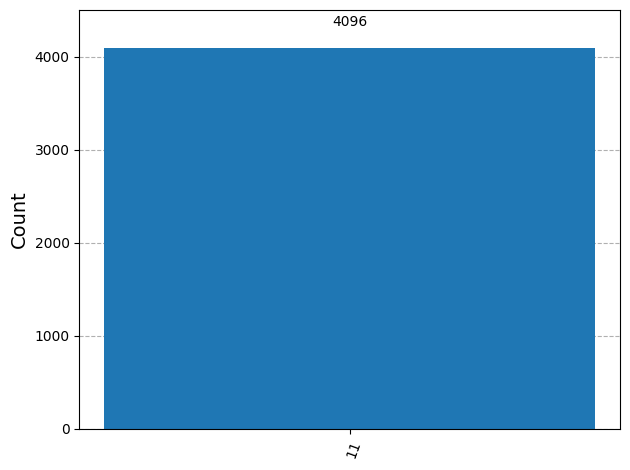

In [86]:
# Plot a histogram of the results
from qiskit.visualization import plot_histogram
plot_histogram(counts_sim)

## Remarks :

Simulation correctly measures a = 3 = 11, which seems like magic, but really it's encoded in the CNOTs between the hadamard layers. Even though now it seems trivial to compute this, the BV algorithm still works if you do the oracle computation, as the hadamards "flip" the CNOTs that the given value of a imposes on the circuit. 

In [87]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Initialize the service
service = QiskitRuntimeService(instance="open-instance")

# Filter for real hardware (not simulators) that is currently operational
backend = service.least_busy(simulator=False, operational=True)
print(f"Running on: {backend.name}")

Running on: ibm_torino


In [88]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_bv = pm.run(bv)

In [89]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
# Initialize the Sampler for your backend
sampler = Sampler(mode=backend)

In [90]:
# Submit the job
job_exp = sampler.run([isa_bv])
job_exp.job_id()

'd6ndrogfh9oc73ep25f0'

In [93]:
job_exp.status()

'DONE'

In [98]:
result_exp = job_exp.result()[0]


In [99]:
# Print the DataBin to see what's inside
list(result_exp.data.keys())

['c18']

In [100]:

counts_exp = result_exp.data.c18.get_counts()
print(counts_exp)

{'11': 3863, '10': 112, '00': 62, '01': 59}


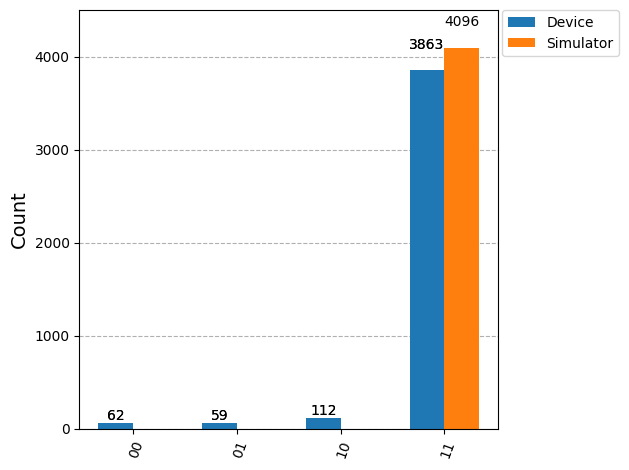

In [101]:
from qiskit.visualization import plot_histogram
plot_histogram([counts_exp,counts_sim], legend=['Device', 'Simulator'])

> Great experimental result. Noise on the device slightly deviates from a = 3, but good enough.

## Question 4. Simon's Algorithm II

> j = 0 as a = 1001, 0th bit is on.

In [1]:
import qiskit
from qiskit import *
import qiskit_ibm_runtime
import qiskit_aer

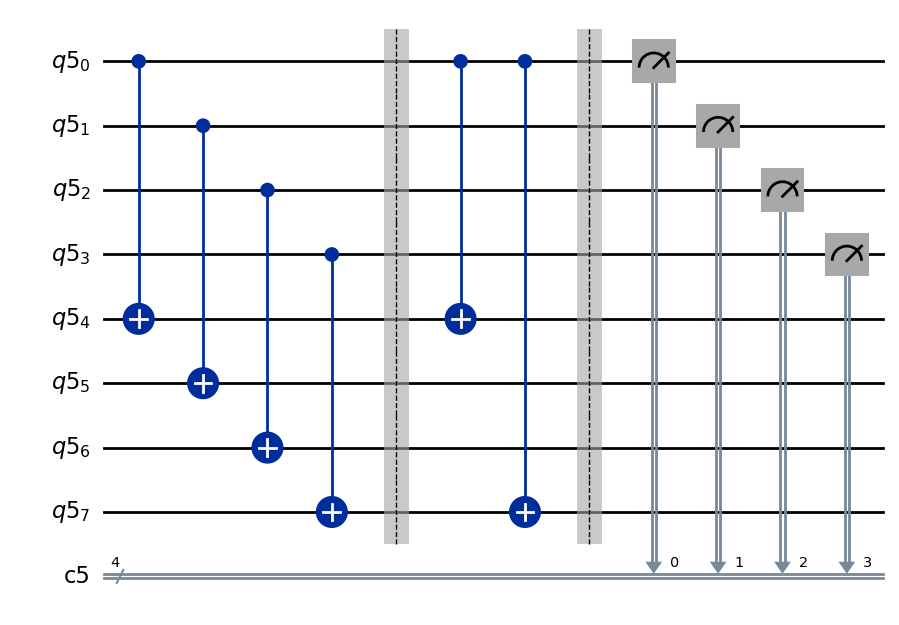

In [8]:

# 4c 

n= 4


q = QuantumRegister(2*n)

c = ClassicalRegister(n)

simon_protocol = QuantumCircuit(q, c)


for i in range(n):
    simon_protocol.cx(q[i], q[i+n])

simon_protocol.barrier()
simon_protocol.cx(q[0], q[n])   # a0 = 1
simon_protocol.cx(q[0], q[3+n])   # a3 = 1

simon_protocol.barrier()

for i in range(n):
    simon_protocol.measure(q[i], c[i])

simon_protocol.draw('mpl')

This is for calculating f(x) for a = 9. Simon's algorithm implemented below. 





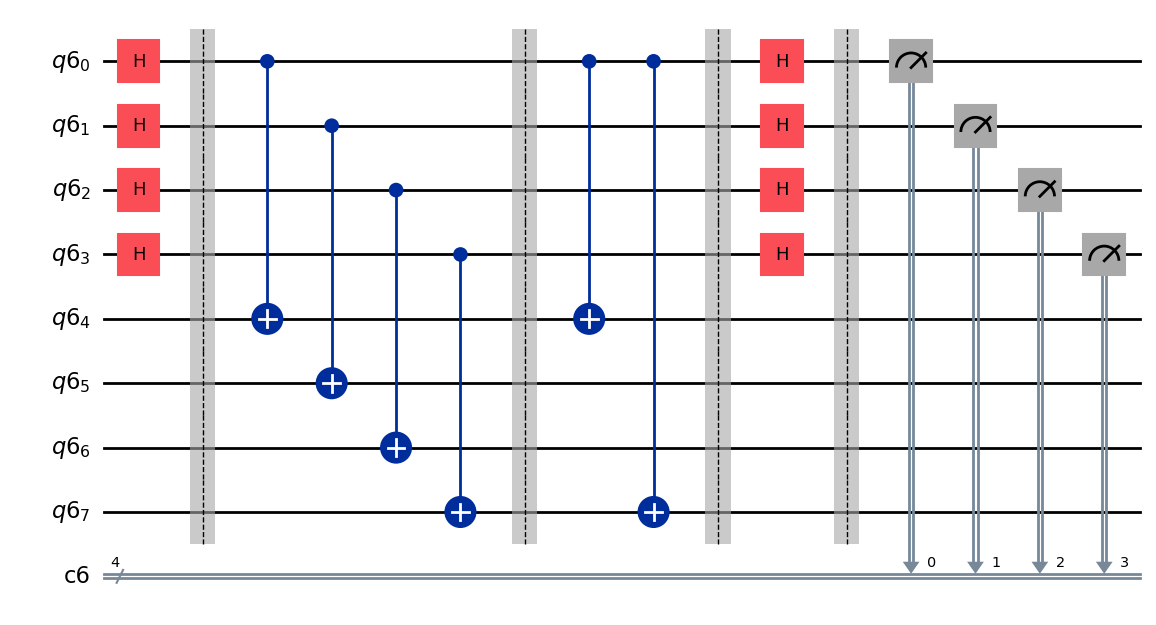

In [9]:

# 4c. for simplicity, let's encode a to be 9, n remains at 4. we can directly port U_f to the circuit.


n= 4


q = QuantumRegister(2*n)

c = ClassicalRegister(n)

simon = QuantumCircuit(q, c)

for i in range(0, n):
    simon.h(q[i])
    
simon.barrier()

for i in range(n):
    simon.cx(q[i], q[i+n])

simon.barrier()

# here is where a is encoded into the circuit. 
simon.cx(q[0], q[n])  
simon.cx(q[0], q[3+n])  

simon.barrier()

for i in range(0, n):
    simon.h(q[i])
    
simon.barrier()

for i in range(n):
    simon.measure(q[i], c[i])

simon.draw('mpl')

In [11]:
simon.draw(initial_state=True)

┌───┐ ░                      ░            ░ ┌───┐ ░ ┌─┐         
q6_0: |0>┤ H ├─░───■──────────────────░───■────■───░─┤ H ├─░─┤M├─────────
         ├───┤ ░   │                  ░   │    │   ░ ├───┤ ░ └╥┘┌─┐      
q6_1: |0>┤ H ├─░───┼────■─────────────░───┼────┼───░─┤ H ├─░──╫─┤M├──────
         ├───┤ ░   │    │             ░   │    │   ░ ├───┤ ░  ║ └╥┘┌─┐   
q6_2: |0>┤ H ├─░───┼────┼────■────────░───┼────┼───░─┤ H ├─░──╫──╫─┤M├───
         ├───┤ ░   │    │    │        ░   │    │   ░ ├───┤ ░  ║  ║ └╥┘┌─┐
q6_3: |0>┤ H ├─░───┼────┼────┼────■───░───┼────┼───░─┤ H ├─░──╫──╫──╫─┤M├
         └───┘ ░ ┌─┴─┐  │    │    │   ░ ┌─┴─┐  │   ░ └───┘ ░  ║  ║  ║ └╥┘
q6_4: |0>──────░─┤ X ├──┼────┼────┼───░─┤ X ├──┼───░───────░──╫──╫──╫──╫─
               ░ └───┘┌─┴─┐  │    │   ░ └───┘  │   ░       ░  ║  ║  ║  ║ 
q6_5: |0>──────░──────┤ X ├──┼────┼───░────────┼───░───────░──╫──╫──╫──╫─
               ░      └───┘┌─┴─┐  │   ░        │   ░       ░  ║  ║  ║  ║ 
q6_6: |0>──────░───────────┤ X ├──┼───░────────┼───░───────░──╫──╫──╫──╫─
               ░           └───┘┌─┴─┐ ░      ┌─┴─┐ ░       ░  ║  ║  ║  ║ 
q6_7: |0>──────░────────────────┤ X ├─░──────┤ X ├─░───────░──╫──╫──╫──╫─
               ░                └───┘ ░      └───┘ ░       ░  ║  ║  ║  ║ 
 c6: 0 4/═════════════════════════════════════════════════════╩══╩══╩══╩═
                                                              0  1  2  3

In [12]:
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

In [13]:
backend = AerSimulator()
sampler = AerSampler()

In [14]:
# Transpile the circuit for the simulator
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
simon_isa = pm.run(simon)

In [15]:
job_sim = sampler.run([simon_isa], shots=4096)
result_sim = job_sim.result()[0] # Get results for the first circuit

In [16]:
# Print the DataBin to see what's inside
list(result_sim.data.keys())

['c6']

In [17]:
counts_sim = result_sim.data.c6.get_counts()
print(counts_sim)

{'0010': 526, '0100': 513, '1101': 527, '0000': 481, '0110': 488, '1011': 502, '1111': 524, '1001': 535}


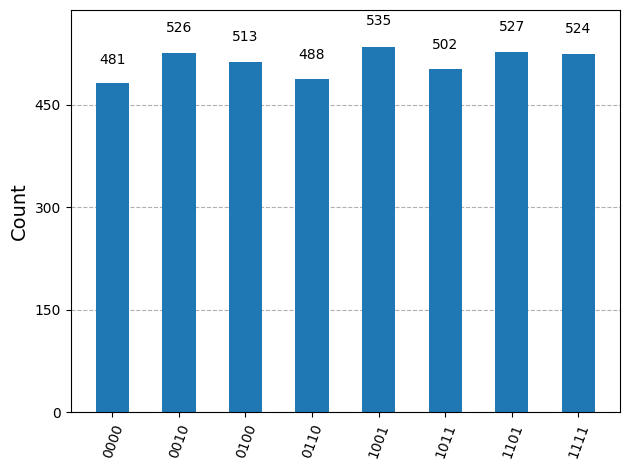

In [18]:
# Plot a histogram of the results
from qiskit.visualization import plot_histogram
plot_histogram(counts_sim)

from the distribution, we get that:

first off,
0010 indicates that a_1 = 0
0100 indicates that a_2 = 0

so x00x = a.

from the rest, we can insert into mathematica.

> MATHEMATICA returns {{a3 -> a0, a1 -> 0, a2 -> 0}}

Which yields a = x00x = a, which we already knew. THank you mathematica.

Ignoring trivial answers, let x = 1, and a = 1001 = 9, the actual value of a that we already knew.
